In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense
from keras.utils import plot_model
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

In [2]:
# Define Diff Function, simplified derivator 
def SimpleDiff(x):
    diff = []
    diff.append(0)
    for i in range(len(x)-1):
        diff.append(x[i+1]-x[i])
    return diff

In [3]:
# import data from vehicle drive, drive manueve lane change 2 times
DataFrame = pd.read_csv("vehicle_drinving_measurement.csv")
print(DataFrame.head(5))
print(f'\n\n')

# Drop the feature wheel forces
DataFrame = DataFrame.drop(['WhlFx_FL', 'WhlFx_RL','WhlFx_FR','WhlFx_RR'], axis=1)
print(DataFrame.head(5))
print(f'\n\n')

# Calculate the derivation
DataFrame['dV'] = SimpleDiff(DataFrame['VehV'])
DataFrame['dSteeringAngle'] = SimpleDiff(DataFrame['SteeringAg'])
#DataFrame['dLatA'] = SimpleDiff(DataFrame['LatA'])
#DataFrame['dYawRate'] = SimpleDiff(DataFrame['YawRate'])
#DataFrame['dLgtA'] = SimpleDiff(DataFrame['LgtA'])
print(DataFrame.head(5))

    VehV  SteeringAg   LatA  YawRate   LgtA  WhlFx_FL  WhlFx_RL  WhlFx_FR  \
0  58.94    0.138866  0.001  0.16588  0.017       117       117       181   
1  58.99    0.138866  0.001  0.31746  0.016       117       100       164   
2  58.85    0.138866  0.000  0.41756  0.015       134       117       181   
3  58.90    0.138866 -0.003  0.51480  0.014       174       149       198   
4  58.95    0.148022 -0.010  0.61204  0.015       194       130       213   

   WhlFx_RR  
0       164  
1       181  
2       198  
3       236  
4       213  



    VehV  SteeringAg   LatA  YawRate   LgtA
0  58.94    0.138866  0.001  0.16588  0.017
1  58.99    0.138866  0.001  0.31746  0.016
2  58.85    0.138866  0.000  0.41756  0.015
3  58.90    0.138866 -0.003  0.51480  0.014
4  58.95    0.148022 -0.010  0.61204  0.015



    VehV  SteeringAg   LatA  YawRate   LgtA    dV  dSteeringAngle
0  58.94    0.138866  0.001  0.16588  0.017  0.00        0.000000
1  58.99    0.138866  0.001  0.31746  0.016  0.05  

In [4]:
# Using PCA to analyse the corolation
# Standarize the data, mean = 0 and std = 1.
StdData = StandardScaler().fit_transform(DataFrame)

# Excute PCA transfomr with origin number of features to get the explained covariance
PCAMdl = PCA(n_components = len(DataFrame.columns))
PCAStdData = PCAMdl.fit_transform(StdData)
print(PCAMdl.explained_variance_ratio_)
# The results shows the dimension of data frame can be down to 8(>98%)

[0.4318771  0.19085304 0.14819078 0.11666707 0.09496586 0.01502544
 0.0024207 ]


In [5]:
# Function create auto encoder model
def CreateAutoEncoderMdl(PeripherieShape):
    # Define input layer
    inputlayer = Input(shape=(PeripherieShape[0],))
    # Define encoder layer
    encoderlayer = Dense(units=PeripherieShape[1],activation='relu')(inputlayer)
    # make sense to add another normalization layer?  
    # Decoder
    decoderlayer = Dense(units=PeripherieShape[0],activation='softmax')(encoderlayer)
    # Define MLP model
    autoencodermdl = Model(inputs=inputlayer, outputs= decoderlayer)
    autoencodermdl.compile(optimizer='adam',loss='mse',metrics=['mse'])
    return autoencodermdl

# Test the function CreateAutoEncoderMdl
#TestMdl = CreateAutoEncoderMdl([8,3])
#TestMdl.summary()    

In [6]:
# create auot encoder model with different number of neurons
NoOfEncoderNeurons = range(1,15)
AutoEncoder4Cluster = [CreateAutoEncoderMdl([len(DataFrame.columns),i]) for i in NoOfEncoderNeurons]
[AutoEncoder4Cluster[i-1].fit(StdData,StdData,batch_size=12, validation_split=0.3,shuffle=False, initial_epoch = 0, epochs=100, verbose=0) for i in NoOfEncoderNeurons]


[0.9150909781455994, 0.8589490056037903, 0.8093626499176025, 0.8140077590942383, 0.7789328694343567, 0.7908592224121094, 0.7799661755561829, 0.7764354944229126, 0.7753192782402039, 0.7766554355621338, 0.7746461033821106, 0.7761884927749634, 0.7741848230361938, 0.774467945098877]


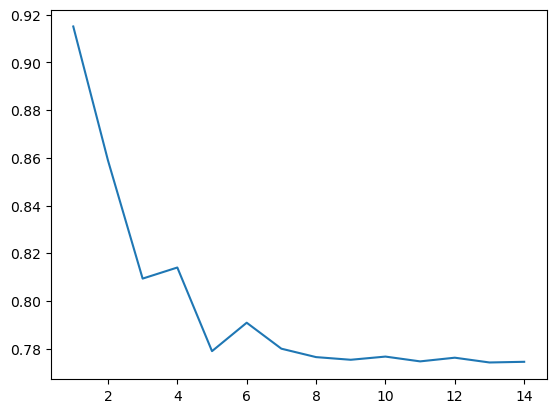

In [7]:
# plot the accuracy of metrics
MeanSquareErr = [entry['loss'] for entry in [AutoEncoder4Cluster[i-1].get_metrics_result() for i in NoOfEncoderNeurons]]
print(MeanSquareErr)
figure1 = plt.figure()
plt.plot([i for i in NoOfEncoderNeurons], MeanSquareErr)

In [8]:
# Function create auto encoder model
def CreateAuto2EncoderMdl(PeripherieShape):
    # Define input layer
    inputlayer = Input(shape=(PeripherieShape[0],))
    # Added an additional layer 
    inbetweenencoderlayer = Dense(units=PeripherieShape[1],activation='relu')(inputlayer)
    # Define encoder layer
    encoderlayer = Dense(units=PeripherieShape[2],activation='relu')(inbetweenencoderlayer)
    # make sense to add another normalization layer?  
    # Added an additional layer 
    inbetweendecoderlayer = Dense(units=PeripherieShape[1],activation='relu')(encoderlayer)
    # Decoder
    decoderlayer = Dense(units=PeripherieShape[0],activation='softmax')(inbetweendecoderlayer)
    # Define MLP model
    autoencodermdl = Model(inputs=inputlayer, outputs= decoderlayer)
    autoencodermdl.compile(optimizer='adam',loss='mse',metrics=['mse'])
    return autoencodermdl

# Test the function CreateAutoEncoderMdl
#TestMdl = CreateAuto2EncoderMdl([5,16,3])
#TestMdl.summary()    

In [9]:
%%script false --no-raise-error

# create auot encoder model with different number of neurons
NoOfEncoderNeurons = range(3,16)
Auto2Encoder4Cluster = [CreateAuto2EncoderMdl([10,32,i]) for i in NoOfEncoderNeurons]
[Auto2Encoder4Cluster[i-3].fit(StdData,StdData,batch_size=12, validation_split=0.3,shuffle=False, initial_epoch = 0, epochs=100, verbose=0) for i in NoOfEncoderNeurons]


In [10]:
%%script false --no-raise-error
# plot the accuracy of metrics
MeanSquareErr = [entry['loss'] for entry in [Auto2Encoder4Cluster[i-3].get_metrics_result() for i in NoOfEncoderNeurons]]
print(MeanSquareErr)
figure2 = plt.figure()
plt.plot([i for i in NoOfEncoderNeurons],MeanSquareErr)
# 3 ~ 9
#[0.843572735786438, 0.8098432421684265, 0.8048208355903625, 0.8078235983848572, 
# 0.7915559411048889, 0.7911765575408936, 0.7877098321914673]

In [11]:
EncoderMdl = Model(inputs=AutoEncoder4Cluster[7].input, outputs=AutoEncoder4Cluster[7].layers[-2].output)
# Summary of the new model
EncoderMdl.summary()


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Evaluate the layer extraction
#EncoderLayer = EncoderMdl.get_layer('dense_46')
#weights, biases = EncoderLayer.get_weights()
#print("Weights:", weights)
#print("Biases:", biases)

#AutoEncoder4Cluster[7].summary()
#EncoderLayer = EncoderMdl.get_layer('dense_46')
#weights, biases = EncoderLayer.get_weights()
#print("Weights:", weights)
#print("Biases:", biases)

In [13]:
# Calculate the output of the encoder layer
PredCluster = EncoderMdl.predict(StdData)
# clustering encoder output 
NumberOfClusters = range(3,32)
KM = [KMeans(n_clusters = i, random_state=1).fit(PredCluster) for i in NumberOfClusters]

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step


Inertia: [27321.400390625, 23322.41015625, 20267.771484375, 18360.01171875, 16714.255859375, 12168.8759765625, 11158.54296875, 10602.2685546875, 9863.330078125, 9220.359375, 8512.265625, 8033.728515625, 7631.05908203125, 7297.92578125, 6781.9853515625, 6632.0068359375, 6463.45166015625, 6062.376953125, 5542.919921875, 5408.6279296875, 5210.99462890625, 5095.697265625, 4929.560546875, 4754.56396484375, 4536.93212890625, 4367.189453125, 4213.35546875, 4138.2197265625, 4022.056884765625]



Silhouette Score: [0.314084, 0.31720796, 0.31653124, 0.3211593, 0.3254794, 0.3897456, 0.39284718, 0.38219795, 0.39245287, 0.39690727, 0.41267404, 0.4090782, 0.41067404, 0.41428554, 0.41353366, 0.40456557, 0.38891152, 0.39420983, 0.37672344, 0.3751328, 0.3742519, 0.3734799, 0.37511545, 0.37878388, 0.38072255, 0.38456896, 0.37728012, 0.37556428, 0.36943978]



Davies-Bouldin Index: [1.2947764291348778, 1.1525762005108242, 1.2230940854812005, 1.1407760348690552, 1.1386494903325932, 0.9633460124587152, 1.0

Text(0.5, 1.0, 'Calinski-Harabasz Index')

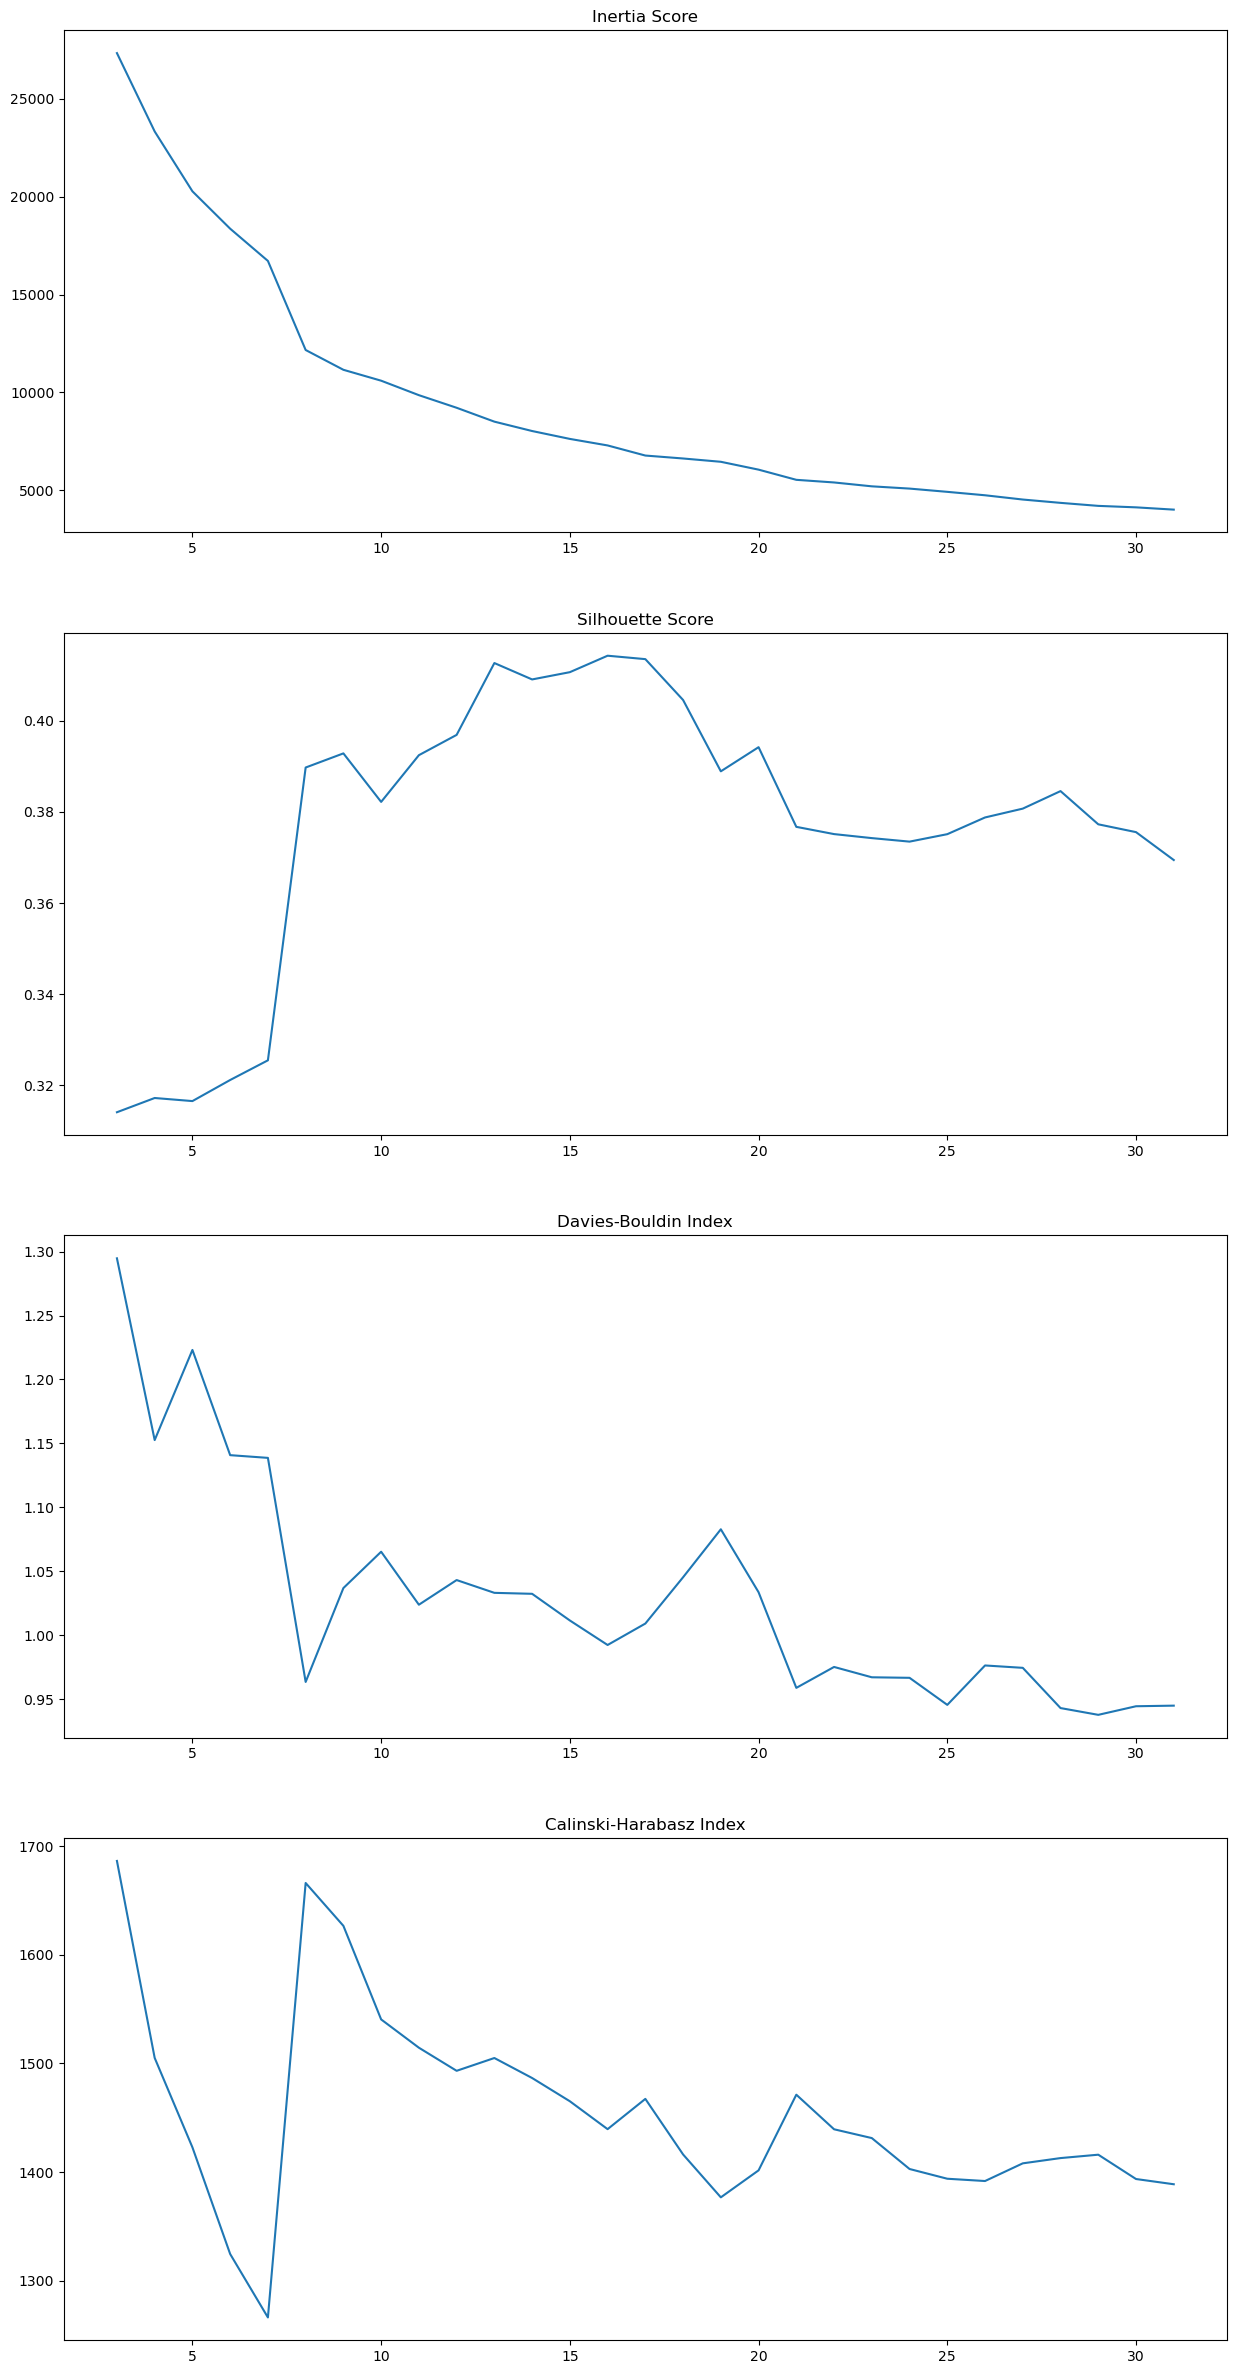

In [14]:
#Inertia measures how tightly the clusters are packed, lower value -> better clustering
InertiaScore = [KM[i-3].inertia_ for i in NumberOfClusters]
print("Inertia:", InertiaScore)
print(f'\n\n')

#The silhouette score measures how similar an object is to its own cluster compared to other clusters, higher value[-1,1] -> better
SilhouetteScore = [silhouette_score(PredCluster, KM[i-3].labels_) for i in NumberOfClusters]
print("Silhouette Score:", SilhouetteScore)
print(f'\n\n')

# Davies-Bouldin Index evaluates the average similarity ratio of each cluster with the cluster 
# that is most similar to it , lower value -> better
DaviesBouldinIndex = [davies_bouldin_score(PredCluster, KM[i-3].labels_) for i in NumberOfClusters]
print("Davies-Bouldin Index:", DaviesBouldinIndex)
print(f'\n\n')

# Variance Ratio Criterion evaluates the ratio of the sum of between-cluster dispersion and within-cluster dispersion
# higher value -> better
CalinskiHarabaszIndex = [calinski_harabasz_score(PredCluster, KM[i-3].labels_) for i in NumberOfClusters]
print("Calinski-Harabasz Index:", CalinskiHarabaszIndex)

figure3 = plt.figure(figsize=(15,30))
plt.subplot(4,1,1)
plt.plot([i for i in NumberOfClusters],InertiaScore)
plt.title("Inertia Score")

plt.subplot(4,1,2)
plt.plot([i for i in NumberOfClusters],SilhouetteScore)
plt.title("Silhouette Score")

plt.subplot(4,1,3)
plt.plot([i for i in NumberOfClusters],DaviesBouldinIndex)
plt.title("Davies-Bouldin Index")

plt.subplot(4,1,4)
plt.plot([i for i in NumberOfClusters],CalinskiHarabaszIndex)
plt.title("Calinski-Harabasz Index")

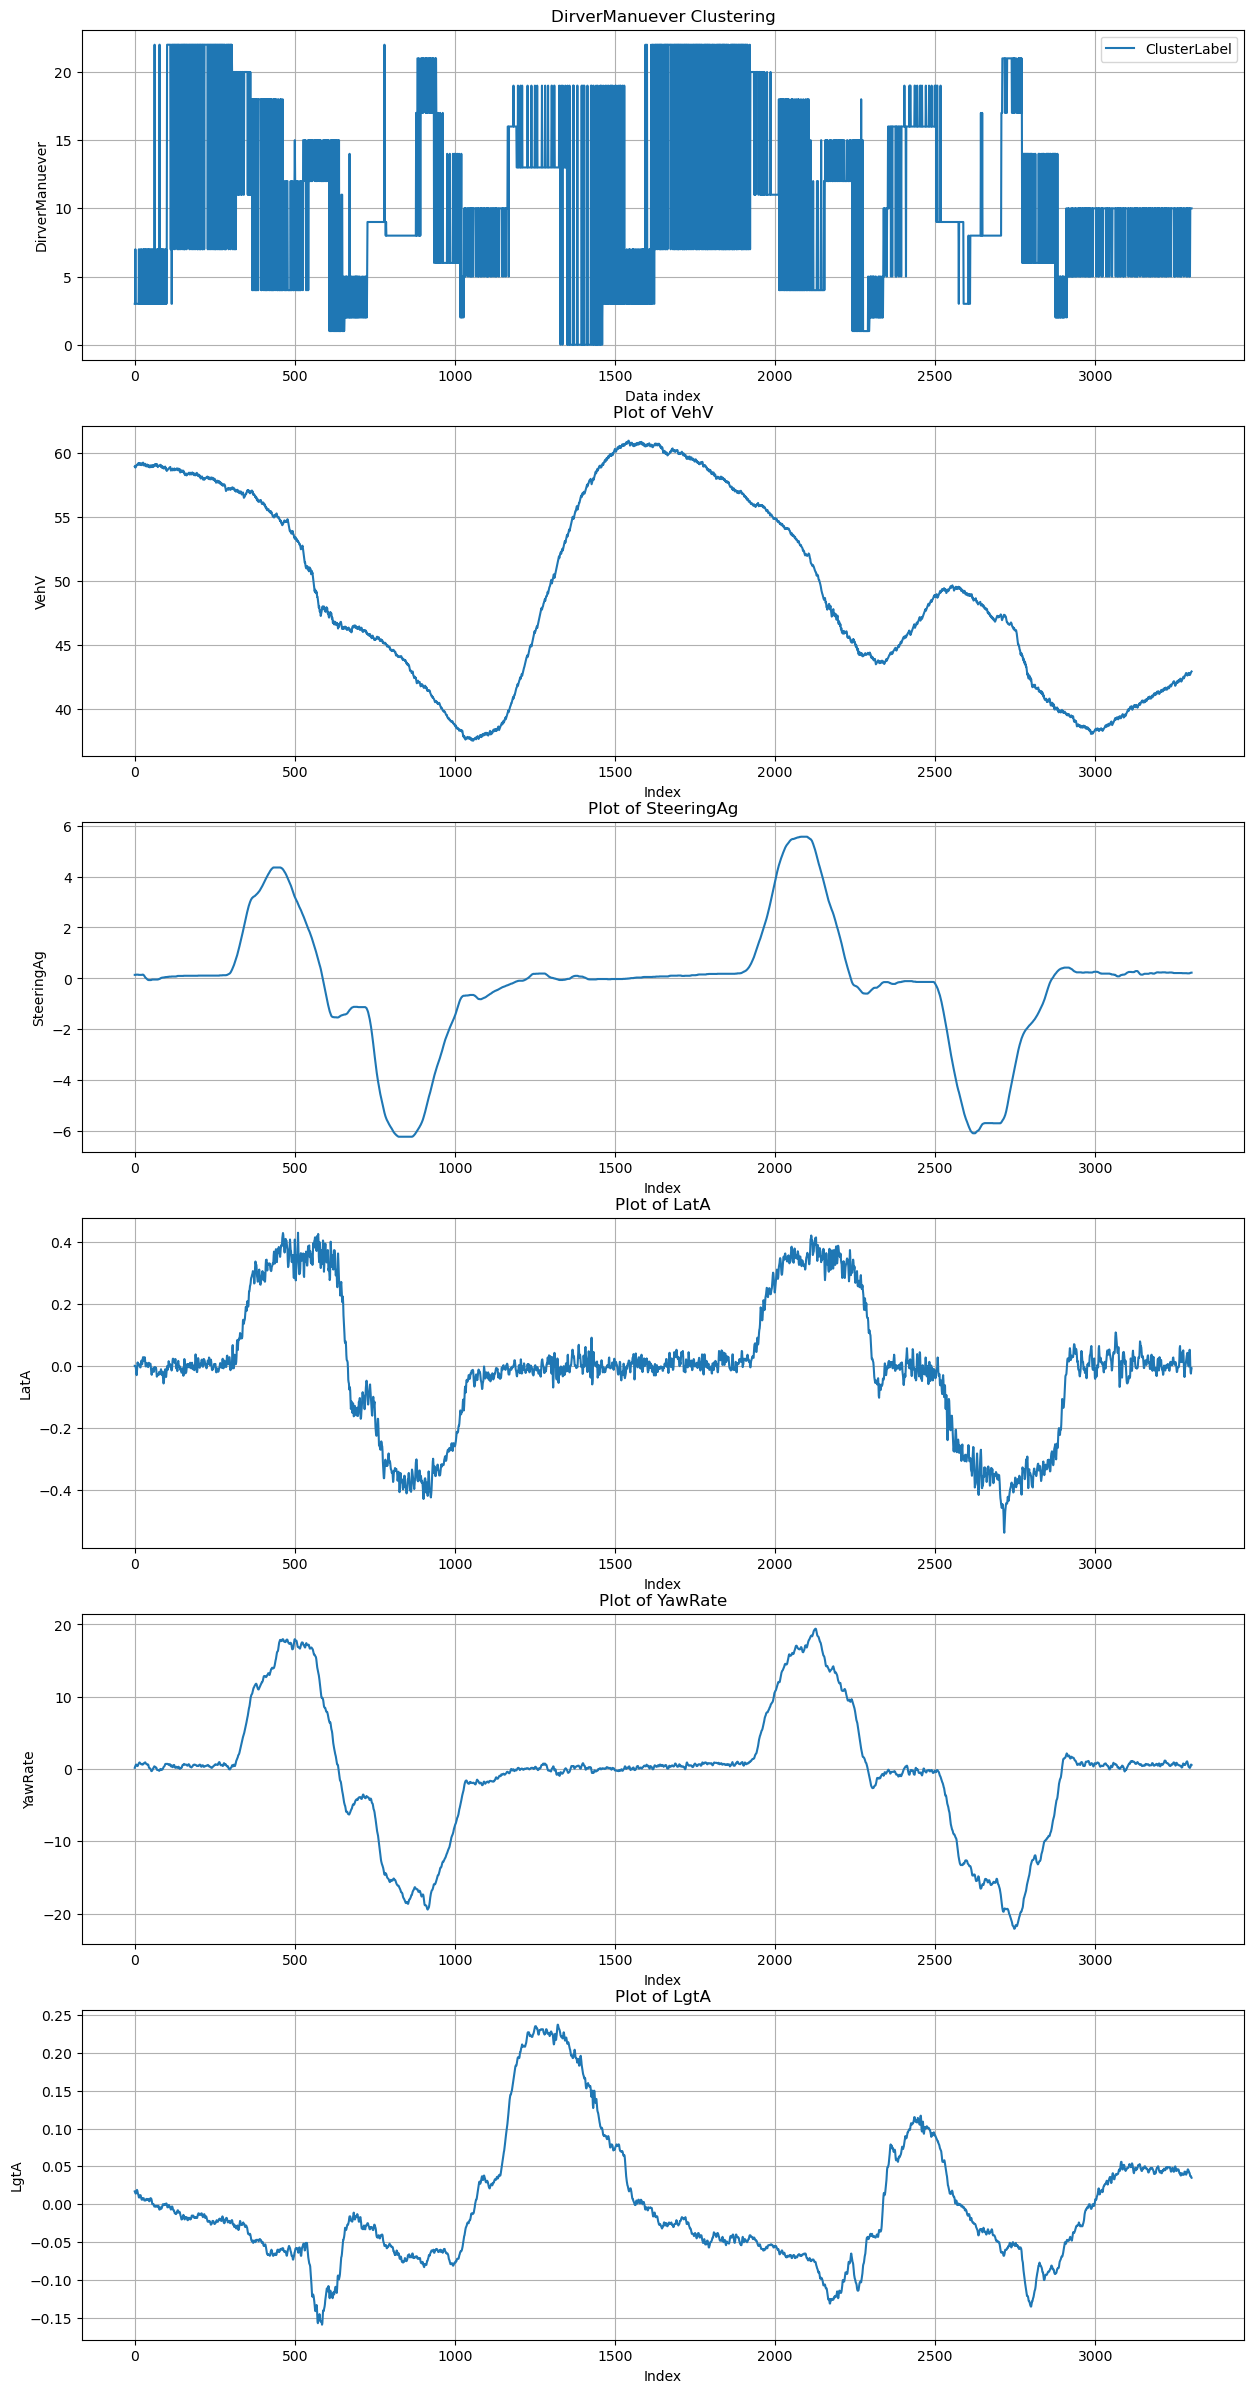

In [15]:
figure4 = plt.figure(figsize=(15,30))
plt.subplot(6,1,1)
plt.plot(KM[20].predict(PredCluster),label='ClusterLabel')
plt.xlabel('Data index')
plt.ylabel('DirverManuever')
plt.title('DirverManuever Clustering')
plt.legend()
plt.grid(True)
i=2;
for column in DataFrame.columns:
    plt.subplot(6,1,i)
    plt.plot(DataFrame[column])
    plt.title(f'Plot of {column}')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.grid(True)
    i += 1
    if i > 6:
        break
plt.savefig('MLClusterDrivingSiuationIdeal_01.png')

In [16]:
print(KM[20].predict(PredCluster))

[ 3  3  7 ... 10 10 10]
